# NBA Statistics Analysis — 2025-26 Season
Analysis of all players scraped from Basketball Reference.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = '/Users/evanjohnson/Documents/personal/NBA_Statistics/NBA_Statistics/2026_player_data'
MIN_GAMES = 20  # minimum games played to qualify for rate-based leaderboards

## Load All Player Data

In [2]:
numeric_cols = ['Margin', 'Minutes', 'FGA', 'FGM', '3PA', '3PM', 'FT', 'FTA',
                'ORB', 'TRB', 'Assists', 'Steals', 'Blocks', 'Turnovers', 'Fouls', 'Points', 'p/m']

frames = []
for fname in os.listdir(DATA_DIR):
    if not fname.endswith('.csv'):
        continue
    player_name = fname[:-4]
    try:
        df = pd.read_csv(os.path.join(DATA_DIR, fname), encoding='utf-8')
        if df.empty:
            continue
        df['Player'] = player_name
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
        frames.append(df)
    except Exception:
        pass

all_games = pd.concat(frames, ignore_index=True)
all_games['Date'] = pd.to_datetime(all_games['Date'], errors='coerce')
all_games['Home'] = (all_games['Home(0)/Away(1)'] == 0)
all_games['Win'] = (all_games['Margin'] > 0)

print(f'Loaded {len(all_games):,} game rows for {all_games["Player"].nunique()} players')
all_games.head(3)

Loaded 23,449 game rows for 533 players


,Date,Team,Opponent,Home(0)/Away(1),Margin,Minutes,FGA,FGM,3PA,3PM,...,Assists,Steals,Blocks,Turnovers,Fouls,Points,p/m,Player,Home,Win
0,2025-10-22,CLE,NYK,1,-8.0,6.72,2.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,2.0,-9.0,Craig Porter,False,False
1,2025-10-24,CLE,BRK,1,7.0,14.42,6.0,6.0,2.0,2.0,...,2.0,1.0,0.0,0.0,0.0,14.0,8.0,Craig Porter,False,True
2,2025-10-26,CLE,MIL,0,5.0,16.35,5.0,2.0,3.0,1.0,...,1.0,3.0,0.0,2.0,1.0,5.0,4.0,Craig Porter,True,True


## League Overview

In [3]:
games_played = all_games.groupby('Player').size().rename('GP')
qualified = games_played[games_played >= MIN_GAMES].index

print(f"Season span:    {all_games['Date'].min().date()}  →  {all_games['Date'].max().date()}")
print(f"Total players:  {all_games['Player'].nunique()}")
print(f"Qualified (≥{MIN_GAMES} GP): {len(qualified)}")
print(f"Total teams:    {all_games['Team'].nunique()}")
print(f"Total games logged: {len(all_games):,}")
print()
print('League averages per game:')
all_games[['Points','Assists','TRB','Steals','Blocks','FGA','3PA','Minutes']].mean().round(1)

Season span:    2025-10-21  →  2026-03-28
Total players:  533
Qualified (≥20 GP): 429
Total teams:    30
Total games logged: 23,449

League averages per game:


Points     10.8
Assists     2.5
TRB         4.1
Steals      0.8
Blocks      0.5
FGA         8.3
3PA         3.5
Minutes    22.5
dtype: float64

## Scoring Leaders

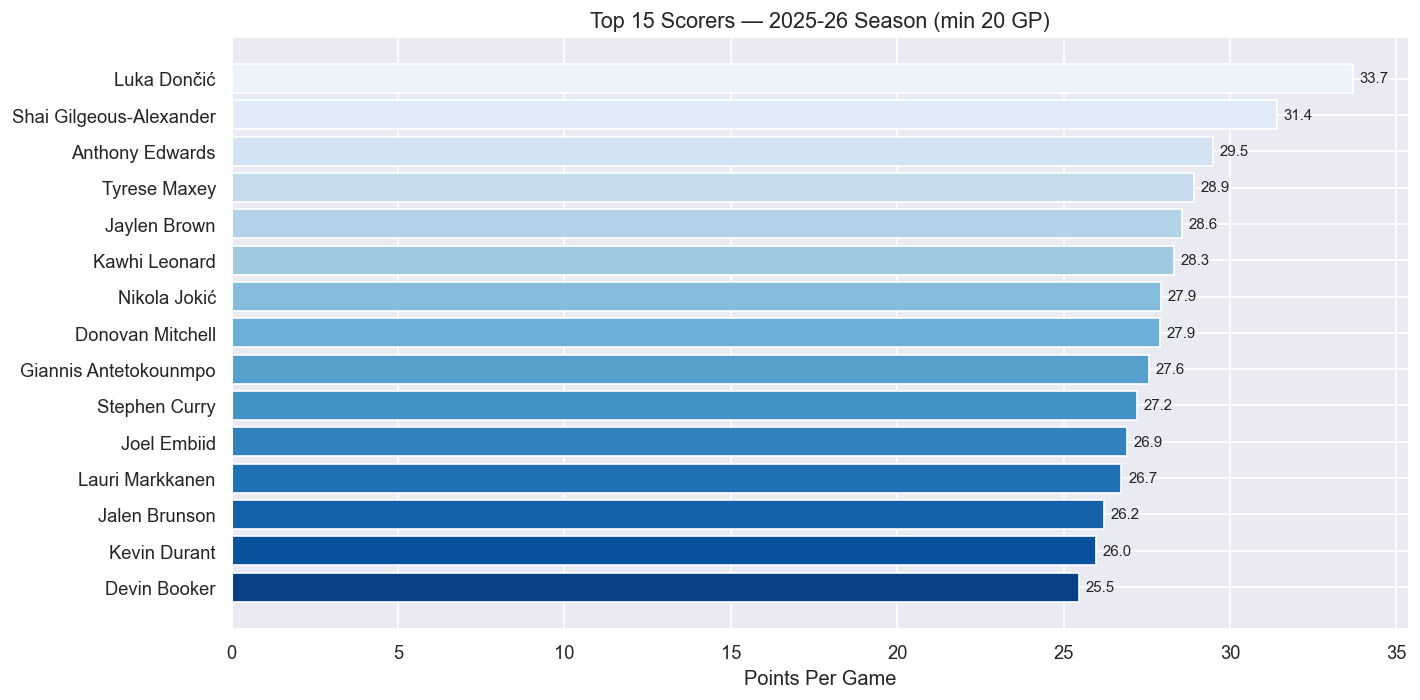

In [4]:
avg_stats = (
    all_games[all_games['Player'].isin(qualified)]
    .groupby('Player')[numeric_cols]
    .mean()
    .round(2)
)
avg_stats['GP'] = games_played
avg_stats['FG%'] = (avg_stats['FGM'] / avg_stats['FGA']).round(3)
avg_stats['3P%'] = (avg_stats['3PM'] / avg_stats['3PA']).round(3)
avg_stats['FT%'] = (avg_stats['FT'] / avg_stats['FTA']).round(3)

top_scorers = avg_stats['Points'].sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_scorers.index[::-1], top_scorers.values[::-1], color=sns.color_palette('Blues_r', 15))
for bar, val in zip(bars, top_scorers.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=9)
ax.set_xlabel('Points Per Game')
ax.set_title(f'Top 15 Scorers — 2025-26 Season (min {MIN_GAMES} GP)', fontsize=13)
plt.tight_layout()
plt.show()

## Shooting Efficiency

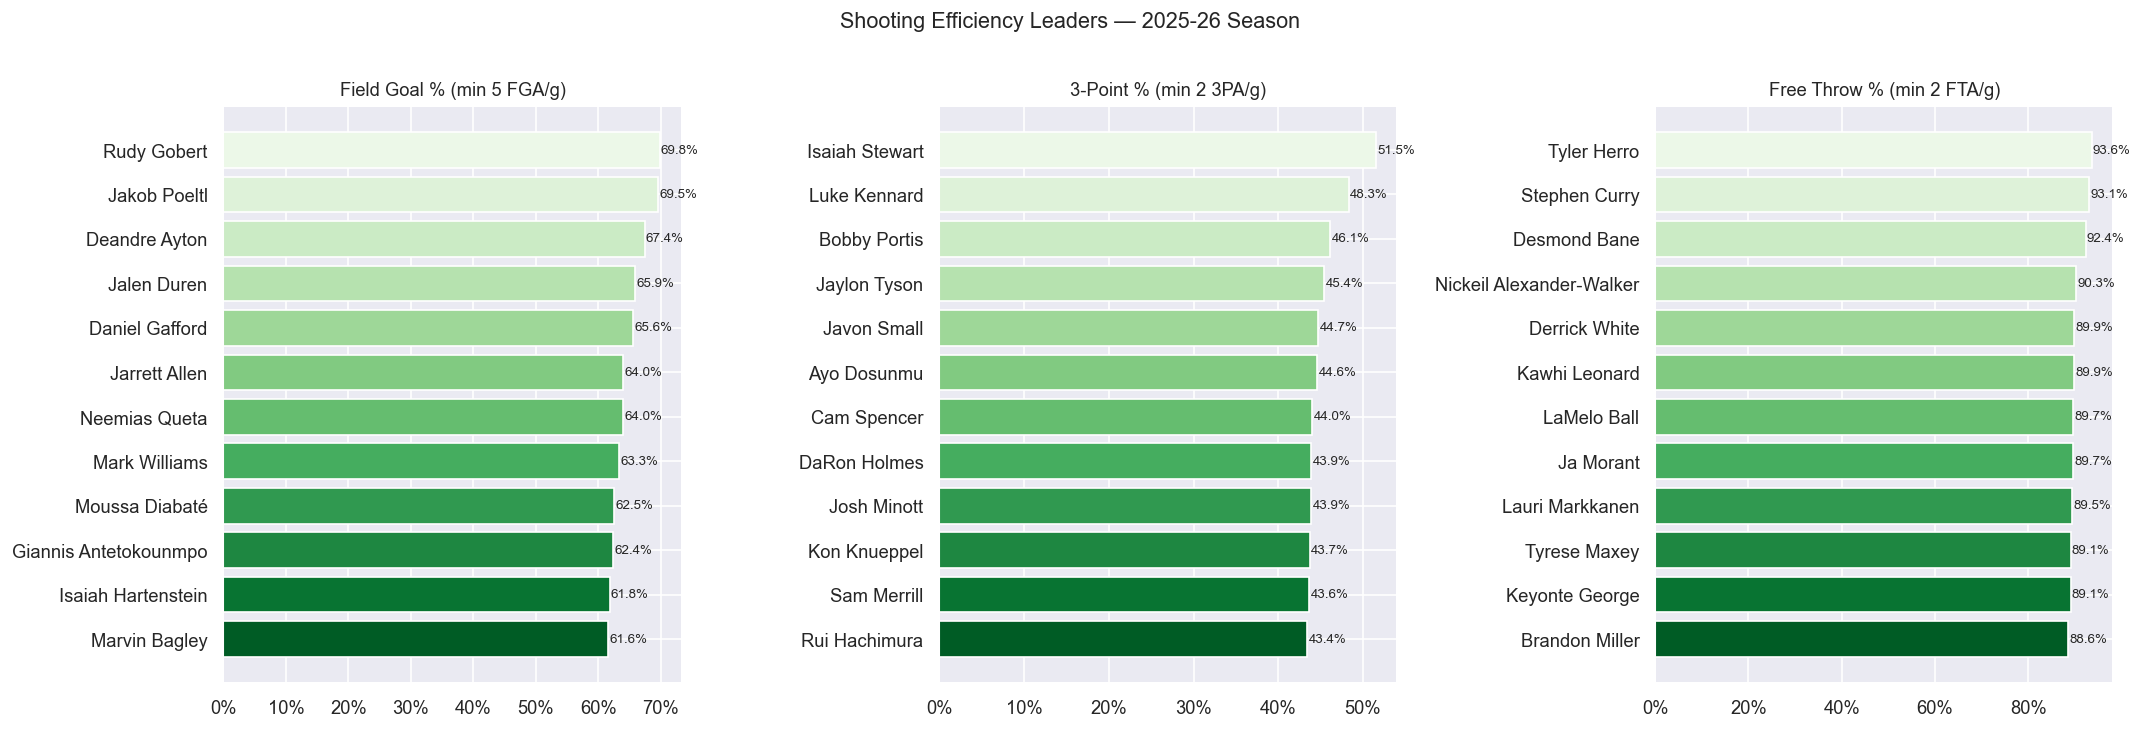

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, title, min_att, att_col in [
    (axes[0], 'FG%',  'Field Goal % (min 5 FGA/g)',  5, 'FGA'),
    (axes[1], '3P%',  '3-Point % (min 2 3PA/g)',     2, '3PA'),
    (axes[2], 'FT%',  'Free Throw % (min 2 FTA/g)',  2, 'FTA'),
]:
    subset = avg_stats[avg_stats[att_col] >= min_att][col].dropna().sort_values(ascending=False).head(12)
    bars = ax.barh(subset.index[::-1], subset.values[::-1], color=sns.color_palette('Greens_r', 12))
    for bar, val in zip(bars, subset.values[::-1]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center', fontsize=8)
    ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.set_title(title, fontsize=11)

plt.suptitle('Shooting Efficiency Leaders — 2025-26 Season', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Scoring vs. Efficiency Scatter

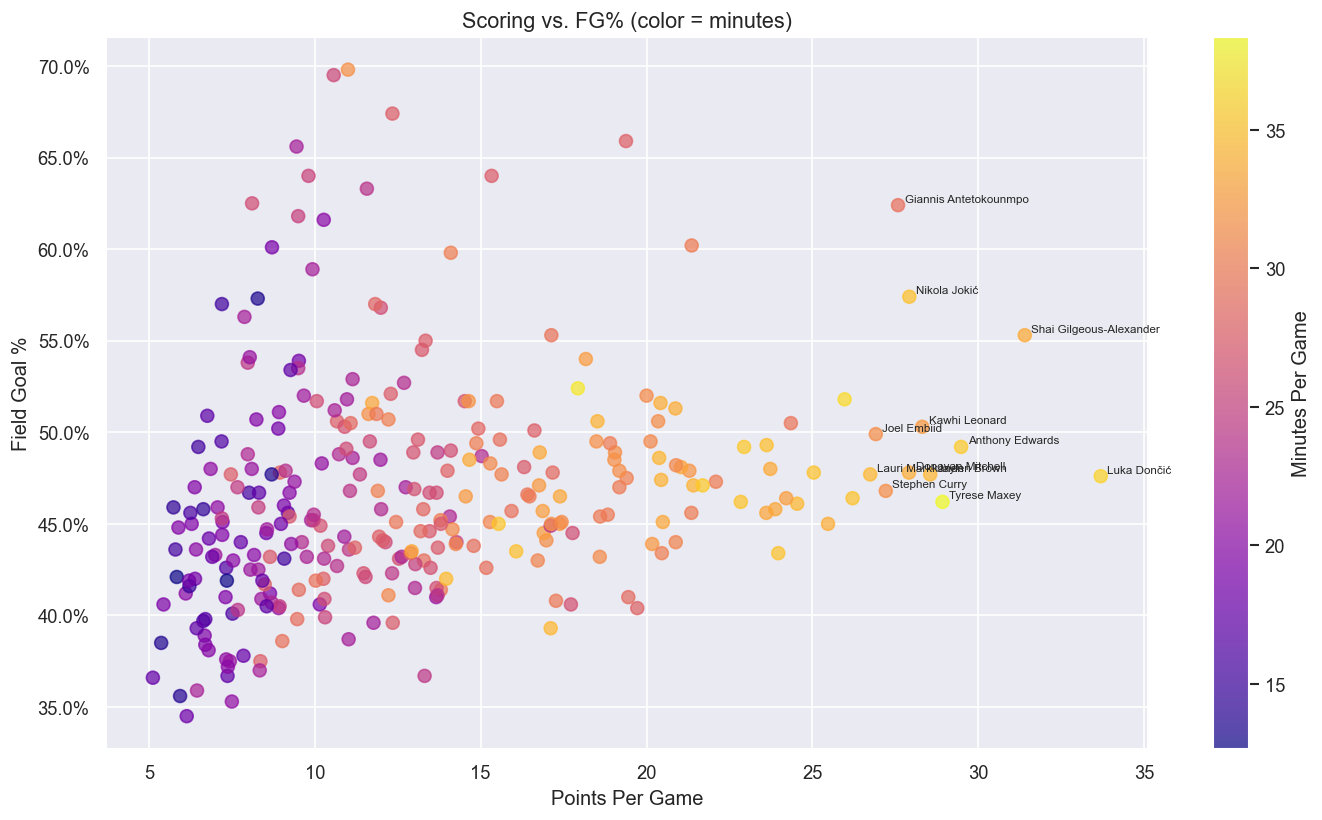

In [6]:
scatter_df = avg_stats[(avg_stats['FGA'] >= 5)].dropna(subset=['FG%', 'Points'])
top_label = scatter_df['Points'].nlargest(12).index

fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(scatter_df['Points'], scatter_df['FG%'], 
                c=scatter_df['Minutes'], cmap='plasma', alpha=0.7, s=60)
for player in top_label:
    ax.annotate(player, (scatter_df.loc[player, 'Points'], scatter_df.loc[player, 'FG%']),
                fontsize=7, ha='left', xytext=(4, 2), textcoords='offset points')
plt.colorbar(sc, ax=ax, label='Minutes Per Game')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.set_xlabel('Points Per Game')
ax.set_ylabel('Field Goal %')
ax.set_title('Scoring vs. FG% (color = minutes)', fontsize=13)
plt.tight_layout()
plt.show()

## Playmaking Leaders

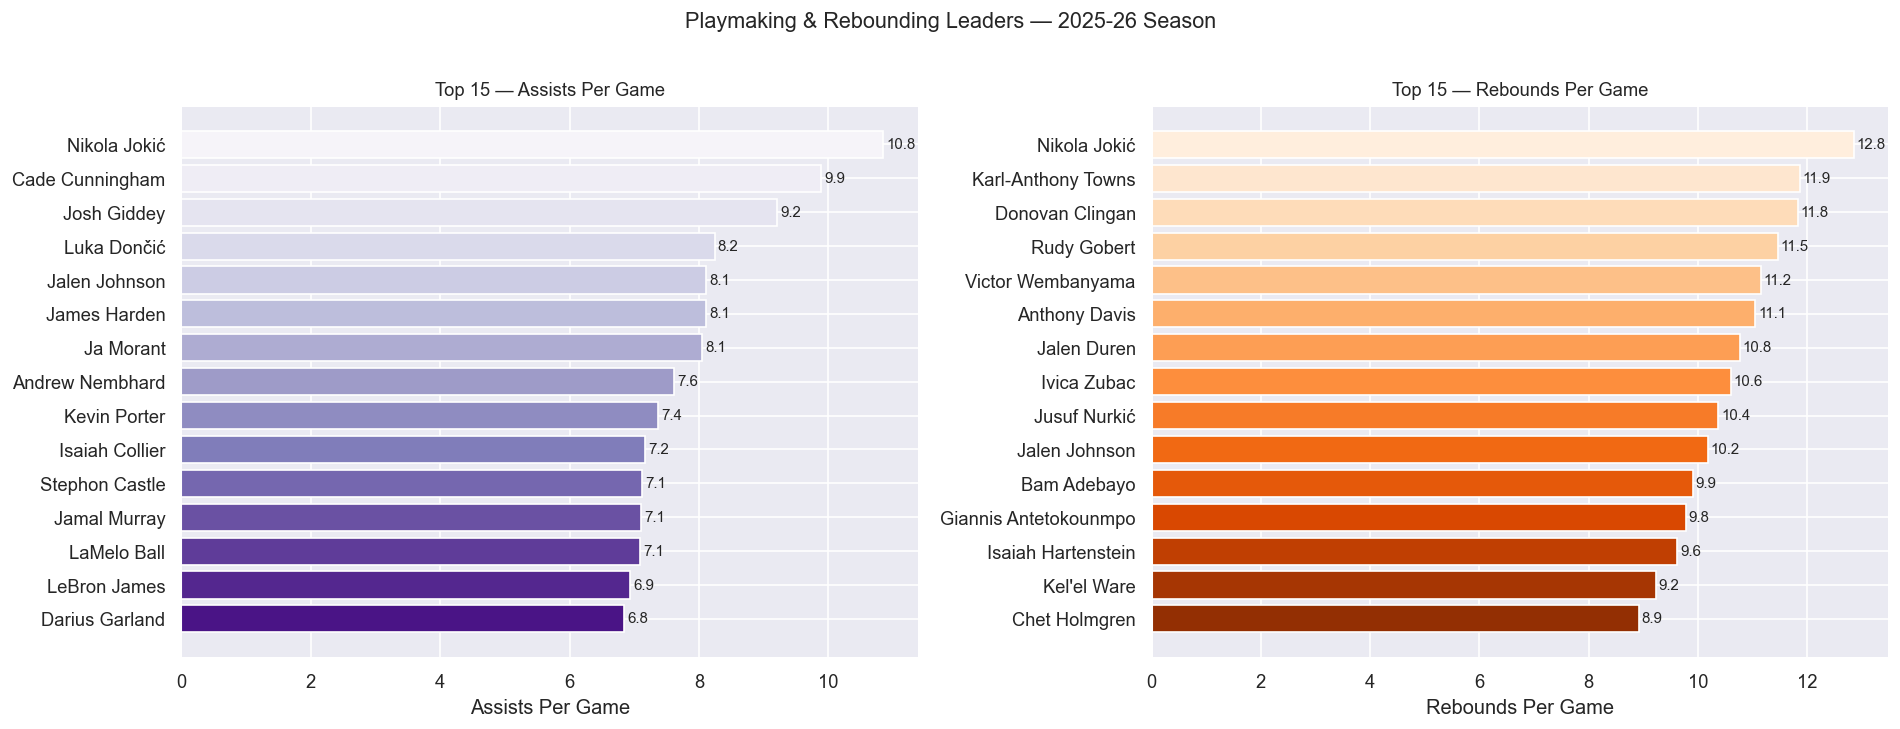

In [7]:
top_ast = avg_stats['Assists'].sort_values(ascending=False).head(15)
top_trb = avg_stats['TRB'].sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, label, palette in [
    (axes[0], top_ast, 'Assists Per Game', 'Purples_r'),
    (axes[1], top_trb, 'Rebounds Per Game', 'Oranges_r'),
]:
    bars = ax.barh(data.index[::-1], data.values[::-1], color=sns.color_palette(palette, 15))
    for bar, val in zip(bars, data.values[::-1]):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=9)
    ax.set_xlabel(label)
    ax.set_title(f'Top 15 — {label}', fontsize=11)

plt.suptitle('Playmaking & Rebounding Leaders — 2025-26 Season', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Defensive Leaders

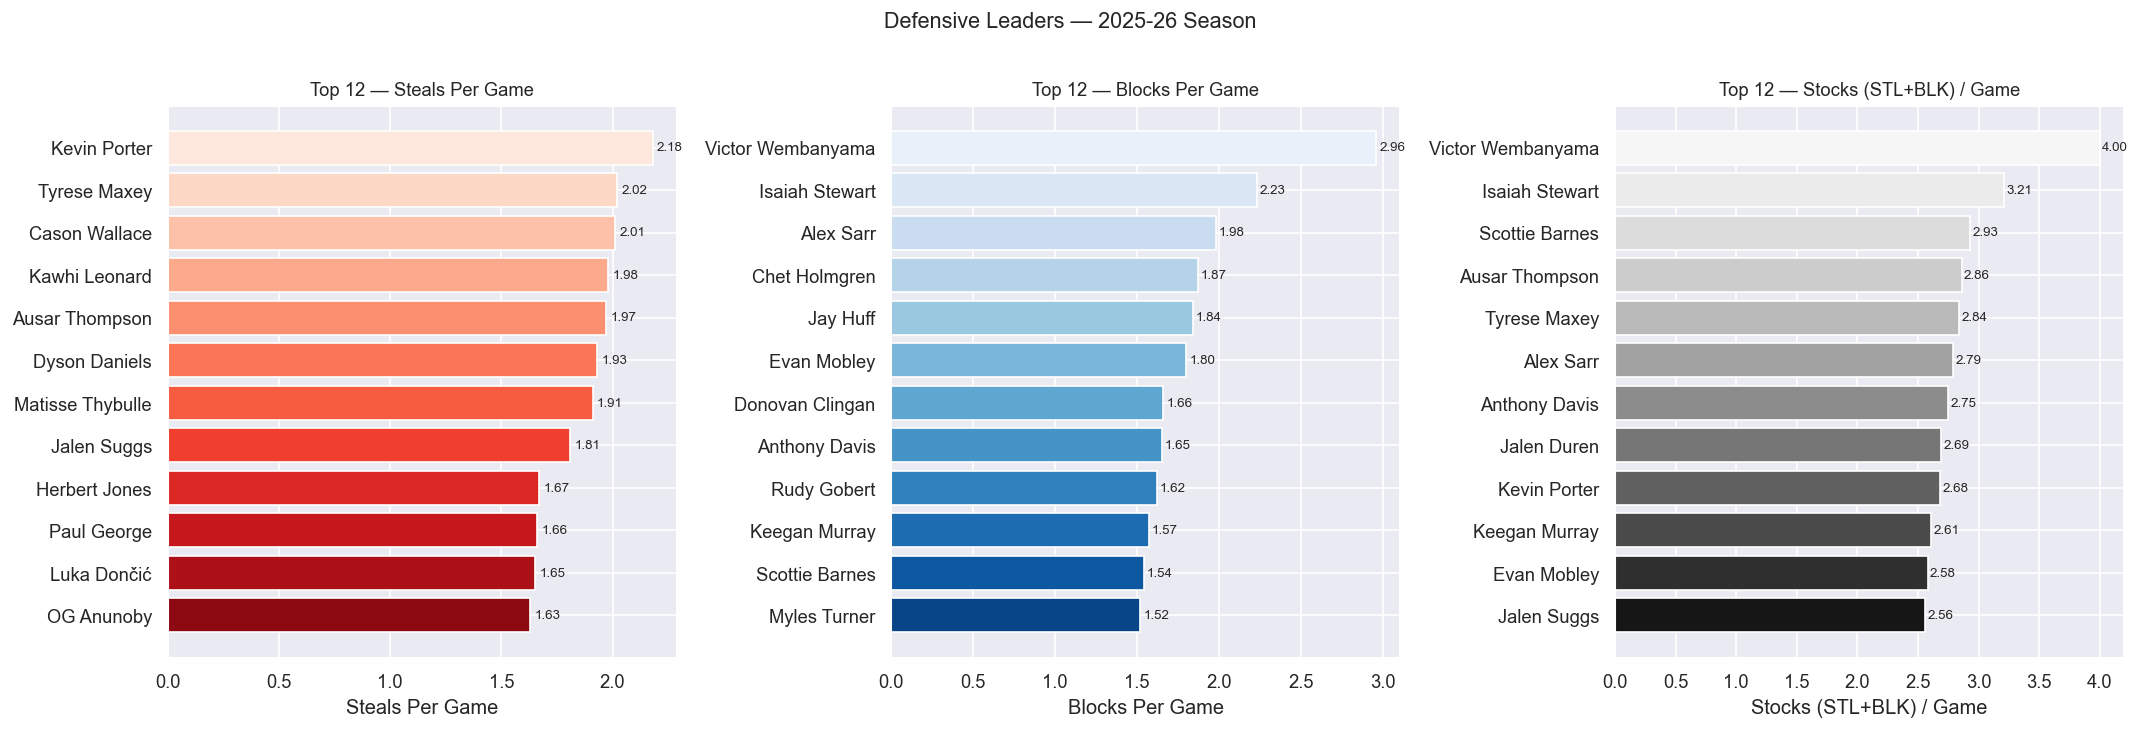

In [8]:
avg_stats['Stocks'] = avg_stats['Steals'] + avg_stats['Blocks']
top_stl = avg_stats['Steals'].sort_values(ascending=False).head(12)
top_blk = avg_stats['Blocks'].sort_values(ascending=False).head(12)
top_stocks = avg_stats['Stocks'].sort_values(ascending=False).head(12)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, data, label, palette in [
    (axes[0], top_stl,    'Steals Per Game',        'Reds_r'),
    (axes[1], top_blk,    'Blocks Per Game',        'Blues_r'),
    (axes[2], top_stocks, 'Stocks (STL+BLK) / Game','Greys_r'),
]:
    bars = ax.barh(data.index[::-1], data.values[::-1], color=sns.color_palette(palette, 12))
    for bar, val in zip(bars, data.values[::-1]):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=8)
    ax.set_xlabel(label)
    ax.set_title(f'Top 12 — {label}', fontsize=11)

plt.suptitle('Defensive Leaders — 2025-26 Season', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Plus / Minus Leaders

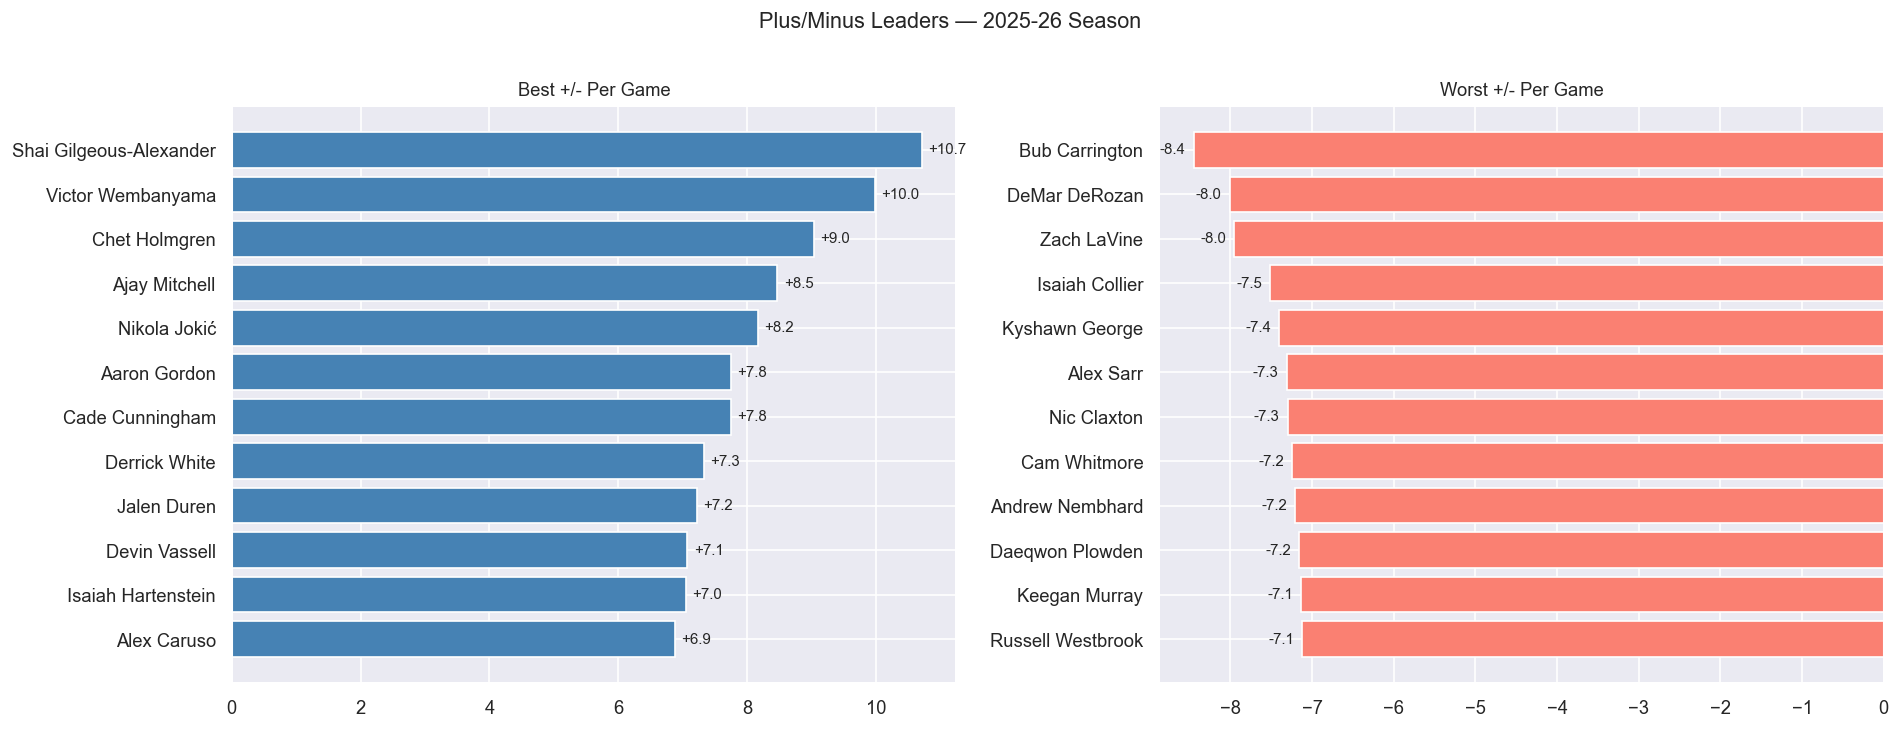

In [9]:
pm = avg_stats['p/m'].dropna().sort_values(ascending=False)
top_pm = pm.head(12)
bot_pm = pm.tail(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].barh(top_pm.index[::-1], top_pm.values[::-1], color='steelblue')
for bar, val in zip(bars, top_pm.values[::-1]):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'{val:+.1f}', va='center', fontsize=9)
axes[0].set_title('Best +/- Per Game', fontsize=11)

bars = axes[1].barh(bot_pm.index, bot_pm.values, color='salmon')
for bar, val in zip(bars, bot_pm.values):
    axes[1].text(bar.get_width() - 0.1, bar.get_y() + bar.get_height()/2, f'{val:+.1f}', va='center', ha='right', fontsize=9)
axes[1].set_title('Worst +/- Per Game', fontsize=11)

plt.suptitle('Plus/Minus Leaders — 2025-26 Season', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Home vs. Away Performance

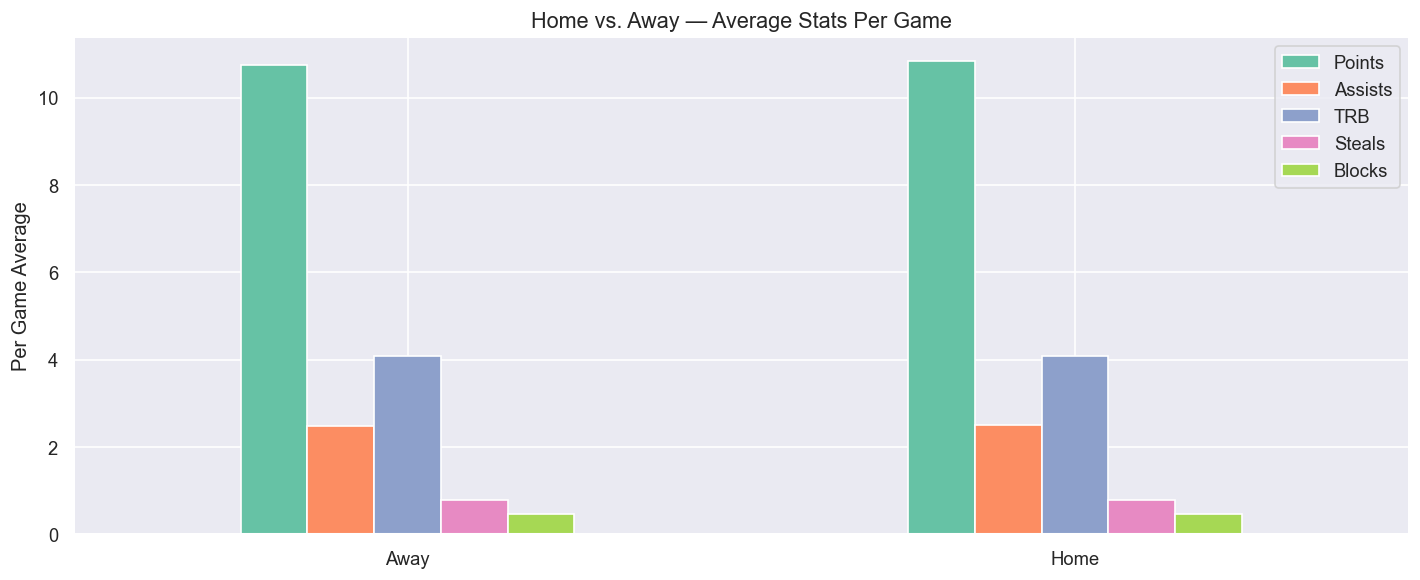

Home vs Away averages:


,Points,Assists,TRB,Steals,Blocks,FG%_game
Away,10.751,2.471,4.091,0.793,0.451,0.458
Home,10.840,2.507,4.079,0.780,0.464,0.462


In [10]:
all_games['FG%_game'] = all_games['FGM'] / all_games['FGA']
ha_stats = all_games.groupby('Home')[['Points','Assists','TRB','Steals','Blocks','FG%_game']].mean().round(3)
ha_stats.index = ['Away', 'Home']

ha_stats[['Points','Assists','TRB','Steals','Blocks']].plot(
    kind='bar', figsize=(12, 5), rot=0,
    color=sns.color_palette('Set2', 5)
)
plt.title('Home vs. Away — Average Stats Per Game', fontsize=13)
plt.ylabel('Per Game Average')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print('Home vs Away averages:')
ha_stats

## Stats in Wins vs. Losses

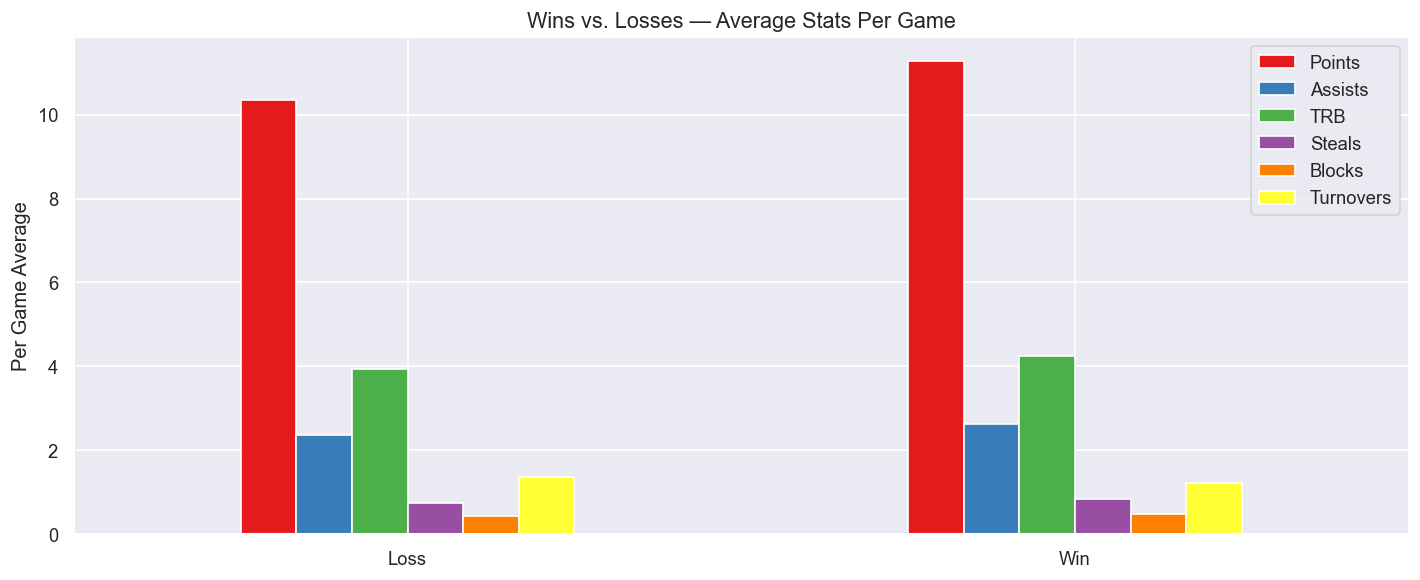

Win vs Loss averages:


,Points,Assists,TRB,Steals,Blocks,Turnovers,FG%_game
Loss,10.348,2.357,3.934,0.739,0.427,1.359,0.437
Win,11.279,2.631,4.248,0.839,0.490,1.221,0.485


In [11]:
wl = all_games.groupby('Win')[['Points','Assists','TRB','Steals','Blocks','Turnovers','FG%_game']].mean().round(3)
wl.index = ['Loss', 'Win']

wl[['Points','Assists','TRB','Steals','Blocks','Turnovers']].plot(
    kind='bar', figsize=(12, 5), rot=0,
    color=sns.color_palette('Set1', 6)
)
plt.title('Wins vs. Losses — Average Stats Per Game', fontsize=13)
plt.ylabel('Per Game Average')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print('Win vs Loss averages:')
wl

## Team Stats

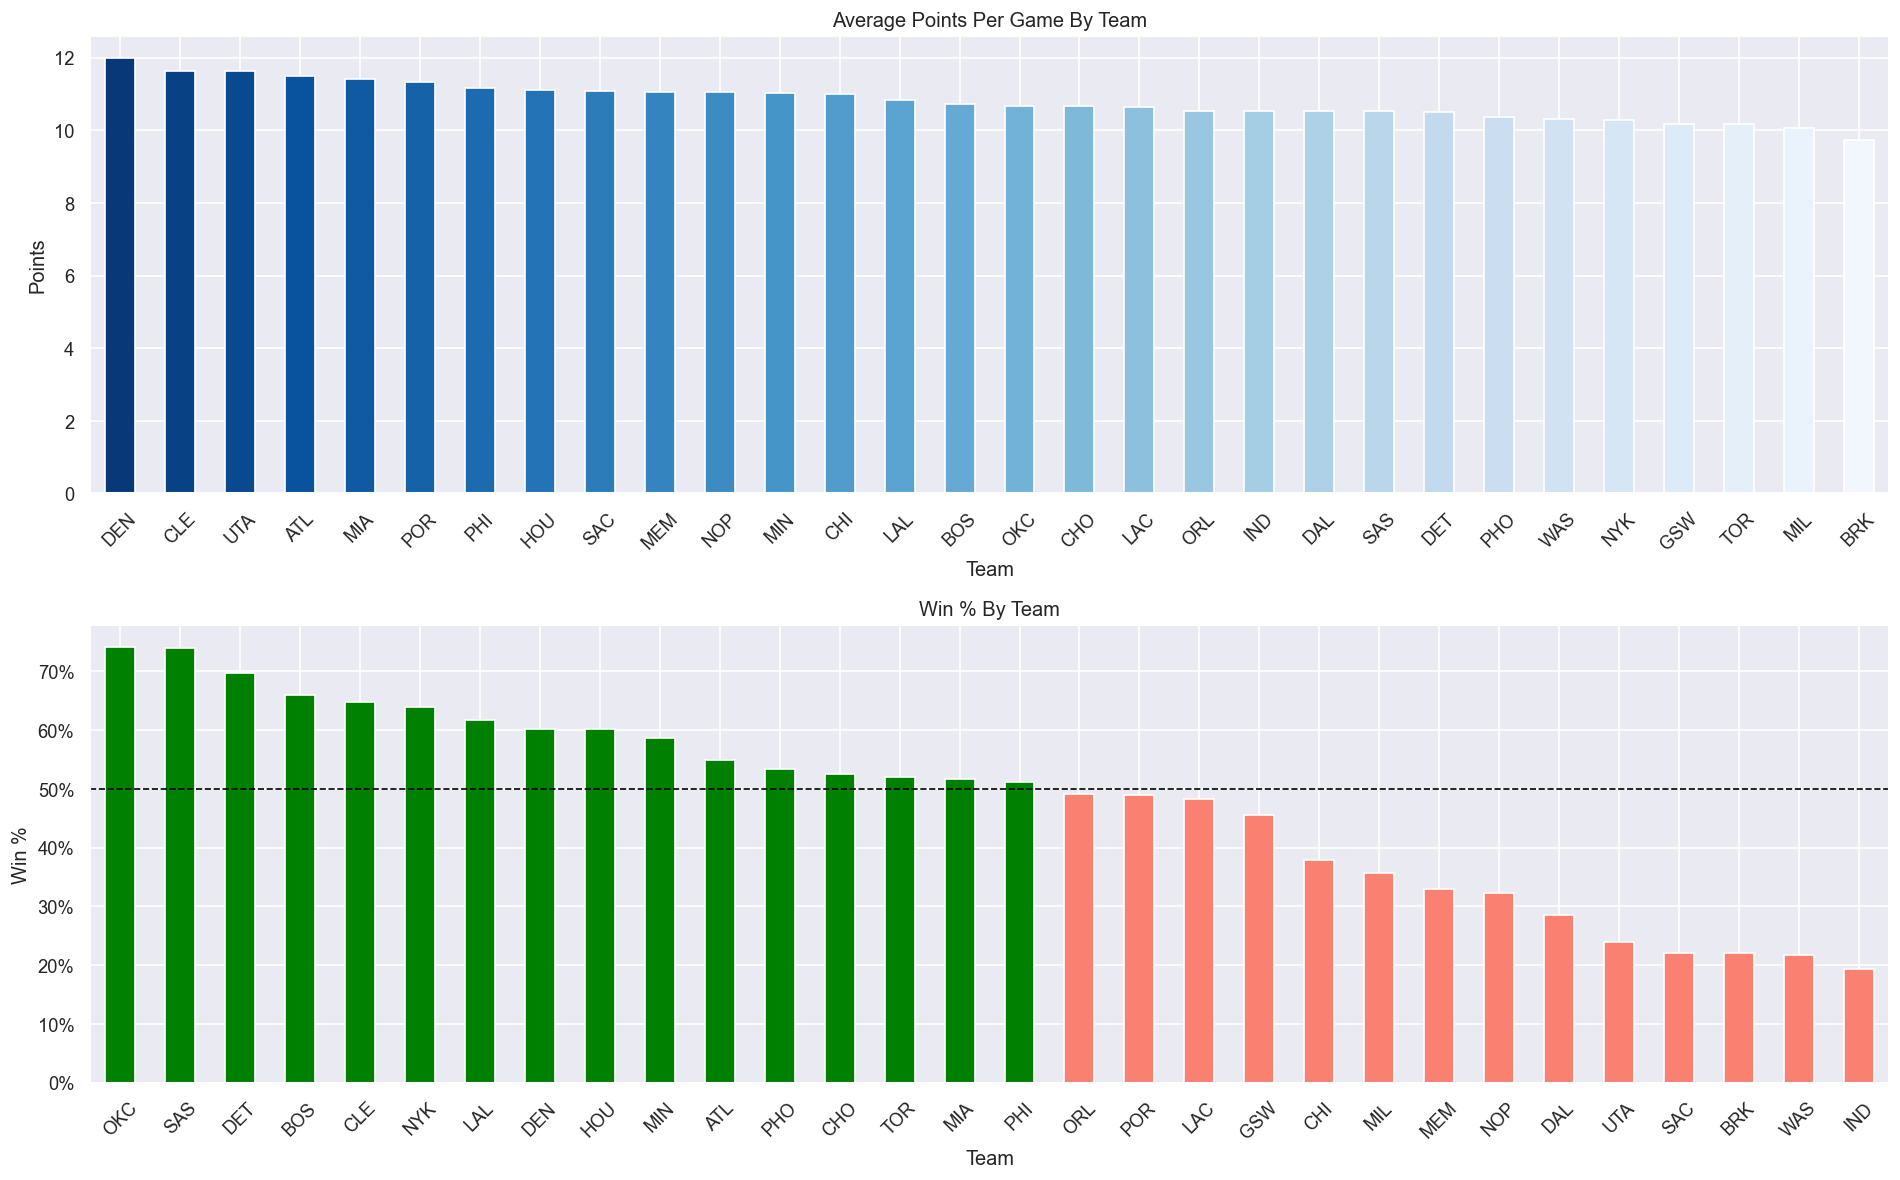


Full team stats table:


,Points,Assists,TRB,Steals,Blocks,Turnovers,Win%
Team,,,,,,,
DEN,11.99,2.83,4.29,0.67,0.39,1.21,0.602
CLE,11.64,2.63,4.19,0.78,0.48,1.25,0.648
UTA,11.63,2.91,4.29,0.86,0.37,1.49,0.240
ATL,11.49,2.95,4.20,0.91,0.45,1.30,0.549
MIA,11.40,2.71,4.41,0.85,0.40,1.26,0.516
POR,11.34,2.48,4.52,0.80,0.53,1.65,0.489
PHI,11.16,2.37,4.18,0.88,0.56,1.25,0.512
HOU,11.12,2.44,4.69,0.85,0.56,1.44,0.602
SAC,11.09,2.61,4.23,0.85,0.49,1.40,0.221


In [12]:
team_stats = all_games.groupby('Team')[['Points','Assists','TRB','Steals','Blocks','Turnovers']].mean().round(2)
team_stats['Win%'] = all_games.groupby('Team')['Win'].mean().round(3)
team_stats = team_stats.sort_values('Points', ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

team_stats['Points'].plot(kind='bar', ax=axes[0], color=sns.color_palette('Blues_r', len(team_stats)), rot=45)
axes[0].set_title('Average Points Per Game By Team', fontsize=12)
axes[0].set_ylabel('Points')

team_stats_by_win = team_stats.sort_values('Win%', ascending=False)
colors = ['green' if w >= 0.5 else 'salmon' for w in team_stats_by_win['Win%']]
team_stats_by_win['Win%'].plot(kind='bar', ax=axes[1], color=colors, rot=45)
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Win % By Team', fontsize=12)
axes[1].set_ylabel('Win %')
axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

print('\nFull team stats table:')
team_stats

## Points Distribution

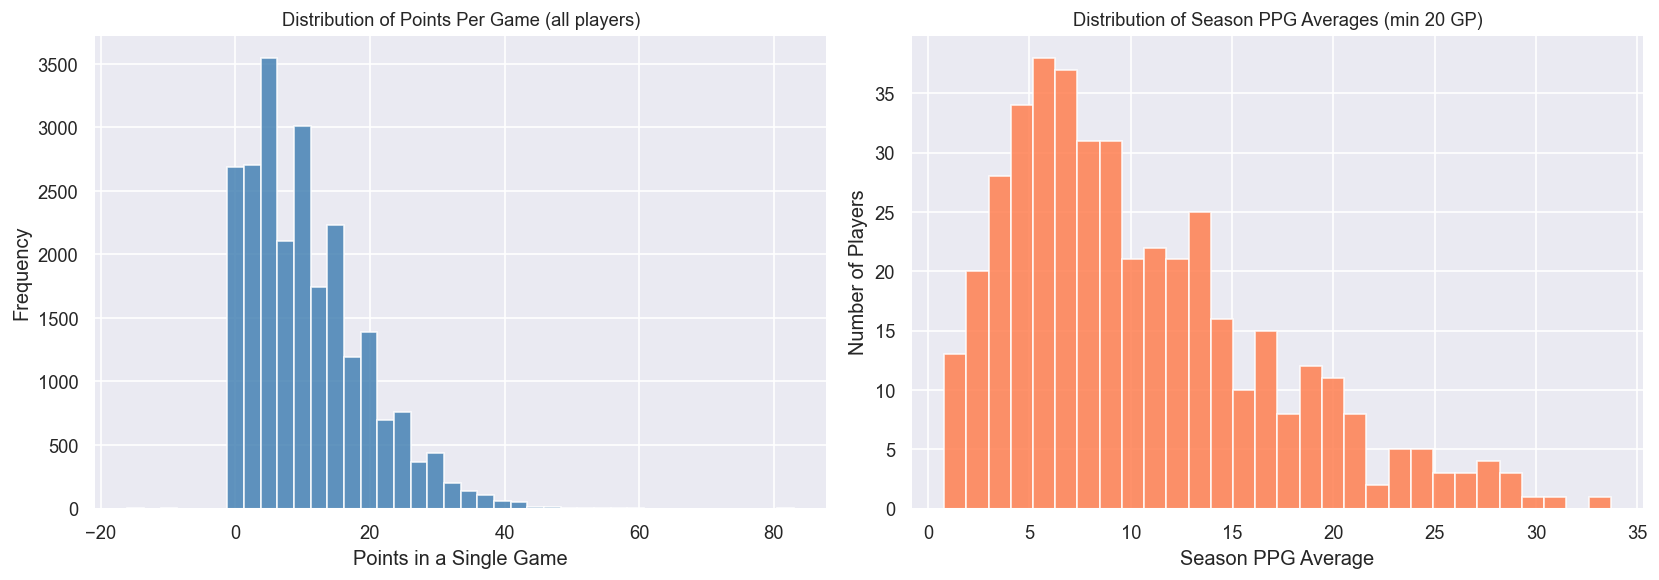

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_games['Points'].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Points in a Single Game')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Points Per Game (all players)', fontsize=11)

axes[1].hist(avg_stats['Points'].dropna(), bins=30, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Season PPG Average')
axes[1].set_ylabel('Number of Players')
axes[1].set_title(f'Distribution of Season PPG Averages (min {MIN_GAMES} GP)', fontsize=11)

plt.tight_layout()
plt.show()

---
## Player Spotlight
Change `PLAYER` below to any player in the dataset.

In [14]:
PLAYER = 'Victor Wembanyama'  # ← change this

player_df = all_games[all_games['Player'] == PLAYER].sort_values('Date').reset_index(drop=True)
if player_df.empty:
    matches = [p for p in all_games['Player'].unique() if PLAYER.lower() in p.lower()]
    print(f'No exact match. Did you mean: {matches[:5]}')
else:
    print(f'{PLAYER} — {len(player_df)} games')
    print(player_df[['Date','Team','Opponent','Points','Assists','TRB','Steals','Blocks','Minutes','p/m']].to_string(index=False))

Victor Wembanyama — 55 games
      Date Team Opponent  Points  Assists  TRB  Steals  Blocks  Minutes   p/m
2025-10-22  SAS      DAL    40.0      1.0 15.0     1.0     3.0    29.68  31.0
2025-10-24  SAS      NOP    29.0      2.0 11.0     1.0     9.0    32.30 -12.0
2025-10-26  SAS      BRK    31.0      4.0 14.0     3.0     6.0    36.47  13.0
2025-10-27  SAS      TOR    24.0      4.0 15.0     1.0     1.0    30.65  35.0
2025-10-30  SAS      MIA    27.0      6.0 18.0     1.0     5.0    39.70   3.0
2025-11-02  SAS      PHO     9.0      2.0  9.0     1.0     4.0    34.45  -3.0
2025-11-05  SAS      LAL    19.0      3.0  8.0     1.0     1.0    32.68  -2.0
2025-11-07  SAS      HOU    22.0      4.0  8.0     1.0     2.0    37.20   5.0
2025-11-08  SAS      NOP    18.0      3.0 18.0     1.0     3.0    32.45   5.0
2025-11-10  SAS      CHI    38.0      5.0 12.0     1.0     5.0    35.92  13.0
2025-11-12  SAS      GSW    31.0     10.0 15.0     0.0     1.0    36.35  -9.0
2025-11-14  SAS      GSW    26.0   

In [15]:
if not player_df.empty:
    season_avg = player_df[['Points','Assists','TRB','Steals','Blocks']].mean().round(2)
    print(f'{PLAYER} season averages:')
    print(season_avg.to_string())
    print(f'\nFG%:  {player_df["FGM"].sum() / player_df["FGA"].sum():.1%}')
    print(f'3P%:  {player_df["3PM"].sum() / player_df["3PA"].sum():.1%}')
    if player_df['FTA'].sum() > 0:
        print(f'FT%:  {player_df["FT"].sum() / player_df["FTA"].sum():.1%}')
    print(f'Win%: {player_df["Win"].mean():.1%}')

Victor Wembanyama season averages:
Points     24.35
Assists     2.91
TRB        11.15
Steals      1.04
Blocks      2.96

FG%:  50.6%
3P%:  35.7%
FT%:  81.7%
Win%: 74.5%


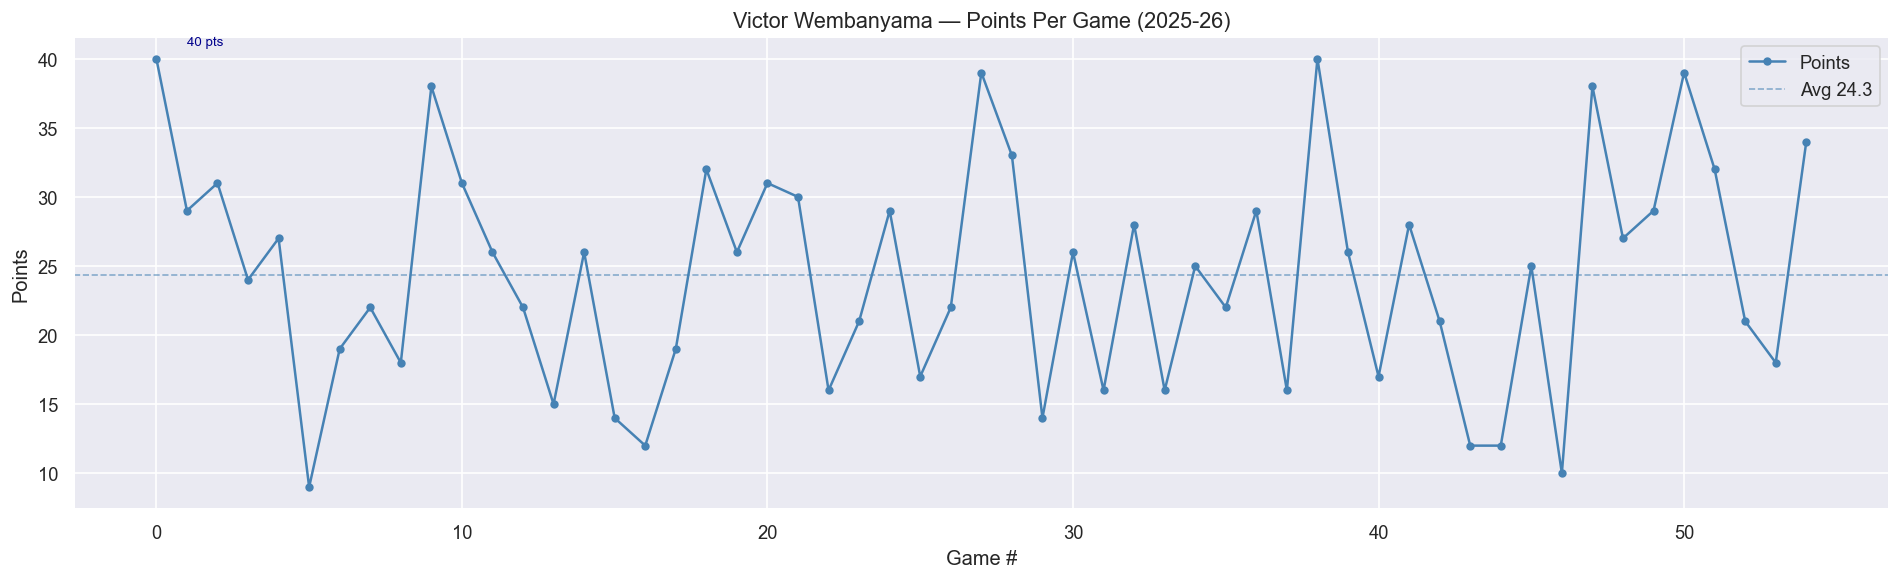

In [16]:
if not player_df.empty:
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(player_df.index, player_df['Points'], marker='o', ms=4, lw=1.5, label='Points', color='steelblue')
    ax.axhline(player_df['Points'].mean(), color='steelblue', linestyle='--', lw=1, alpha=0.6, label=f'Avg {player_df["Points"].mean():.1f}')
    ax.set_xlabel('Game #')
    ax.set_ylabel('Points')
    ax.set_title(f'{PLAYER} — Points Per Game (2025-26)', fontsize=13)
    ax.legend()
    peak_i = player_df['Points'].idxmax()
    ax.annotate(f"{int(player_df.loc[peak_i,'Points'])} pts",
                xy=(peak_i, player_df.loc[peak_i,'Points']),
                xytext=(peak_i+1, player_df.loc[peak_i,'Points']+1),
                fontsize=8, color='darkblue')
    plt.tight_layout()
    plt.show()

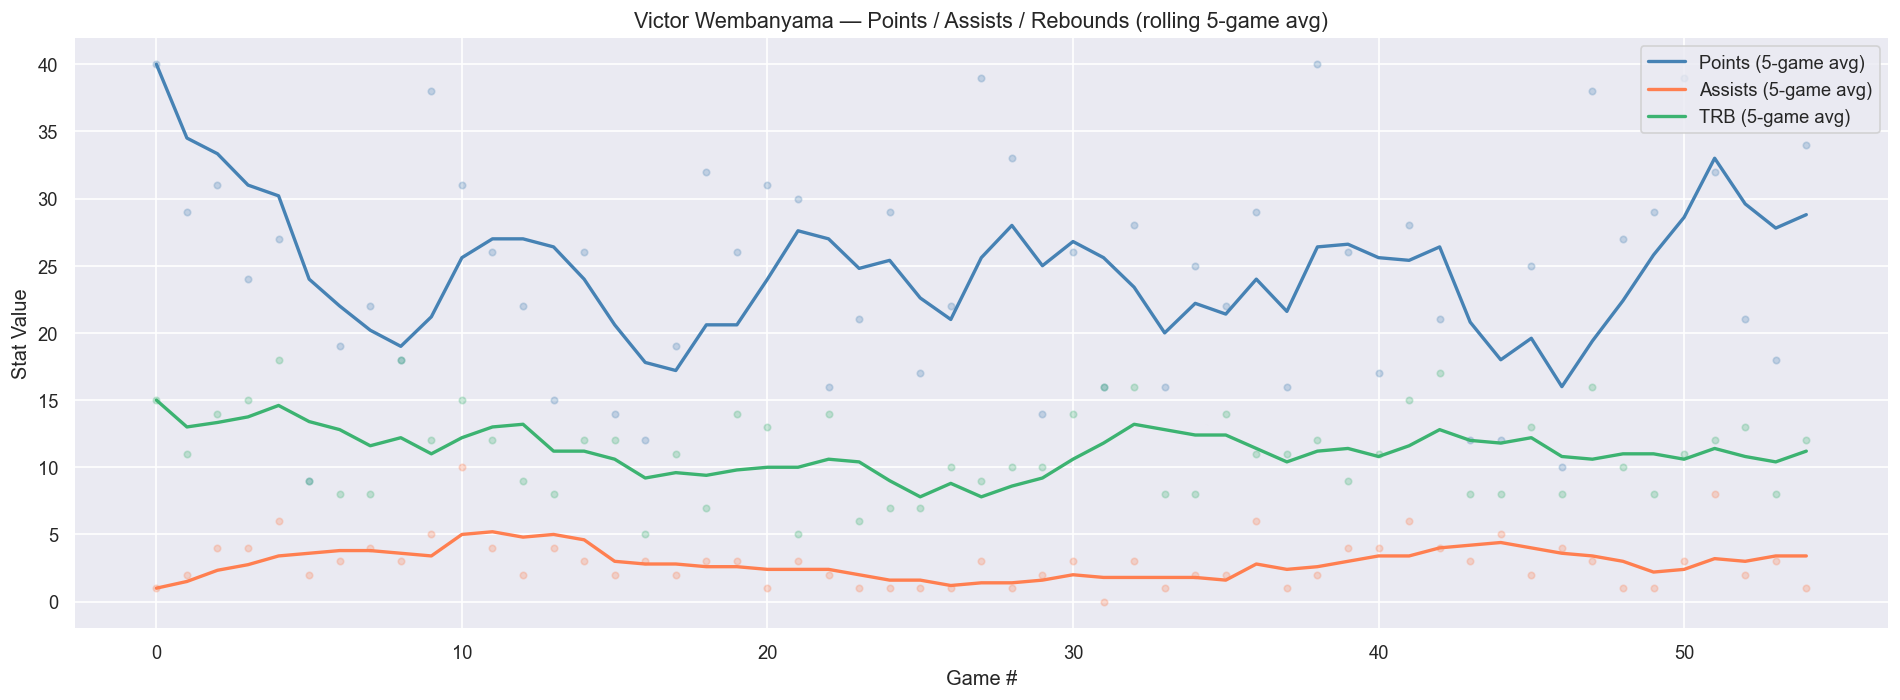

In [17]:
if not player_df.empty:
    STATS = ['Points', 'Assists', 'TRB']
    colors = ['steelblue', 'coral', 'mediumseagreen']

    fig, ax = plt.subplots(figsize=(16, 6))
    for stat, color in zip(STATS, colors):
        rolling = player_df[stat].rolling(5, min_periods=1).mean()
        ax.plot(player_df.index, rolling, label=f'{stat} (5-game avg)', color=color, lw=2)
        ax.scatter(player_df.index, player_df[stat], alpha=0.25, s=15, color=color)

    ax.set_xlabel('Game #')
    ax.set_ylabel('Stat Value')
    ax.set_title(f'{PLAYER} — Points / Assists / Rebounds (rolling 5-game avg)', fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Correlation Heatmap

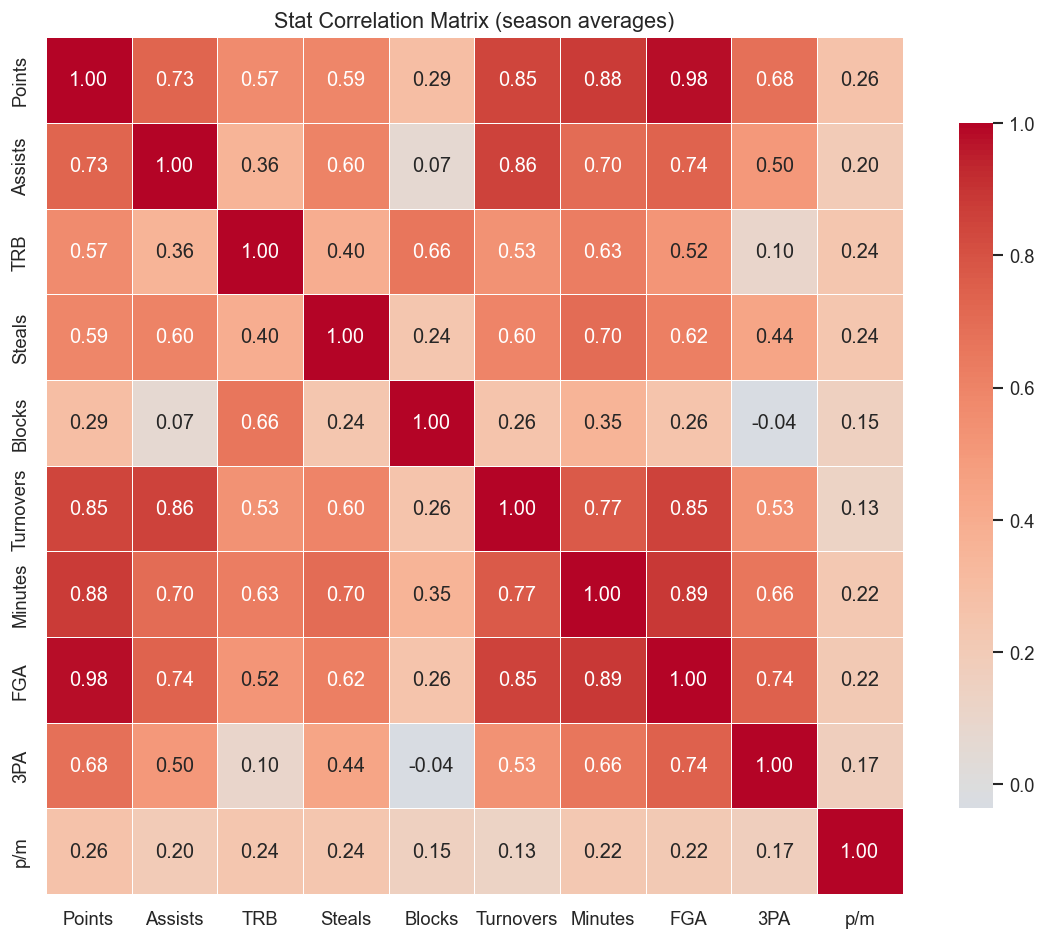

In [18]:
corr_cols = ['Points', 'Assists', 'TRB', 'Steals', 'Blocks', 'Turnovers', 'Minutes', 'FGA', '3PA', 'p/m']
corr = avg_stats[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Stat Correlation Matrix (season averages)', fontsize=13)
plt.tight_layout()
plt.show()